# 3b. Baseline Evaluation - RandomForest

Evaluate the baseline RandomForest with multiclass metrics/plots and binary Normal-vs-Anomaly analysis.

In [1]:
import os, numpy as np, pandas as pd, joblib, pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize

base_dir = os.path.join('..')
splits_dir = os.path.join(base_dir, 'data', 'splits')
models_dir = os.path.join(base_dir, 'models')

In [2]:
le = joblib.load(os.path.join(models_dir, 'label_encoder.pkl'))
selected_features = joblib.load(os.path.join(models_dir, 'selected_features.pkl'))
rf = joblib.load(os.path.join(models_dir, 'baseline_rf_model.pkl'))

class_names = le.classes_.tolist()
num_classes = len(class_names)

test_df = pd.read_csv(os.path.join(splits_dir, 'test.csv'))
X_test = test_df[selected_features].values
y_test = test_df['label'].values.astype(int)

print('Loaded test data:', X_test.shape)
print('Classes:', class_names)

Loaded test data: (82332, 30)
Classes: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


In [3]:
y_pred = rf.predict(X_test)
probs = rf.predict_proba(X_test)

def metrics_dict(y_true, y_pred):
    return {
        'acc': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

metrics = metrics_dict(y_test, y_pred)
print('Baseline RF test metrics:', metrics)
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

Baseline RF test metrics: {'acc': 0.730141378807754, 'precision_macro': 0.5301826575713338, 'recall_macro': 0.5787627658268796, 'f1_macro': 0.5152093985604529, 'f1_weighted': 0.7703608876149384}
                precision    recall  f1-score   support

      Analysis       0.03      0.07      0.04       677
      Backdoor       0.05      0.45      0.09       583
           DoS       0.36      0.17      0.23      4089
      Exploits       0.75      0.66      0.70     11132
       Fuzzers       0.28      0.62      0.38      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.97      0.72      0.82     37000
Reconnaissance       0.90      0.81      0.86      3496
     Shellcode       0.31      0.74      0.43       378
         Worms       0.66      0.57      0.61        44

      accuracy                           0.73     82332
     macro avg       0.53      0.58      0.52     82332
  weighted avg       0.85      0.73      0.77     82332



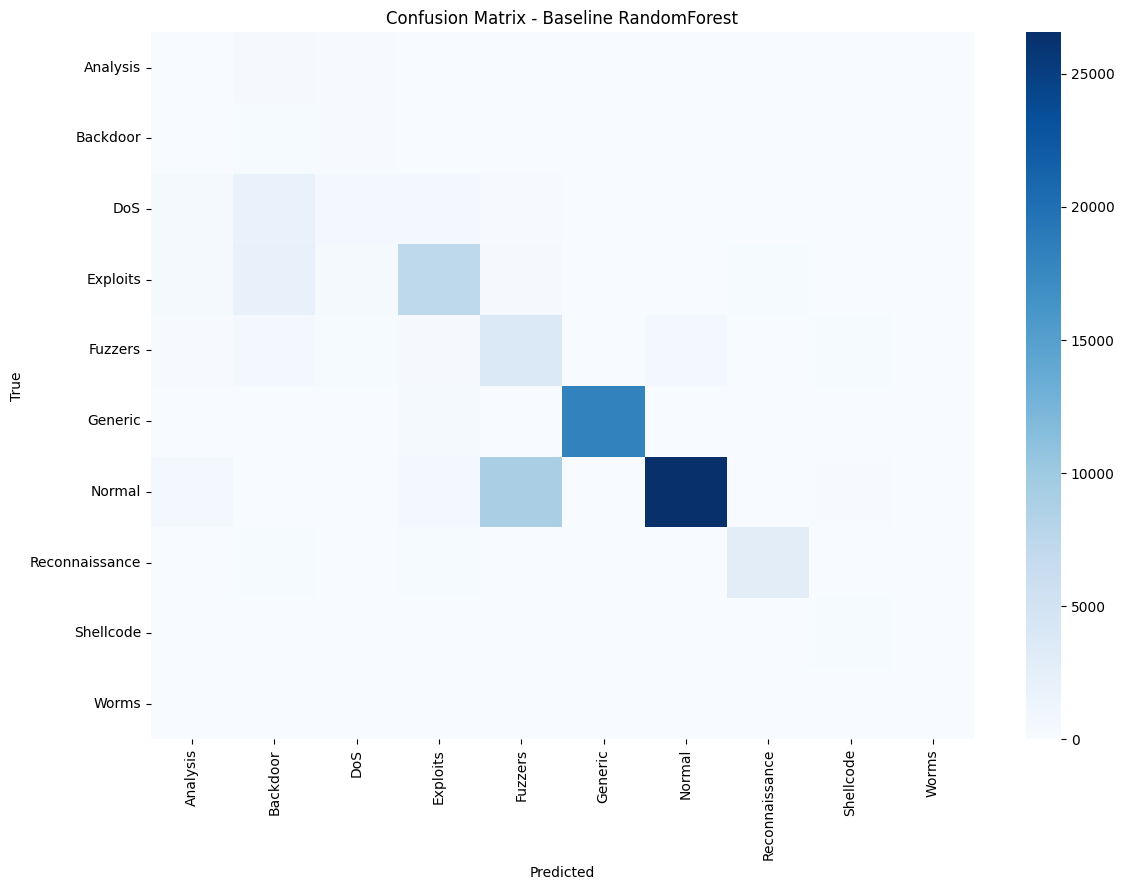

In [4]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Baseline RandomForest')
plt.tight_layout()
plt.show()

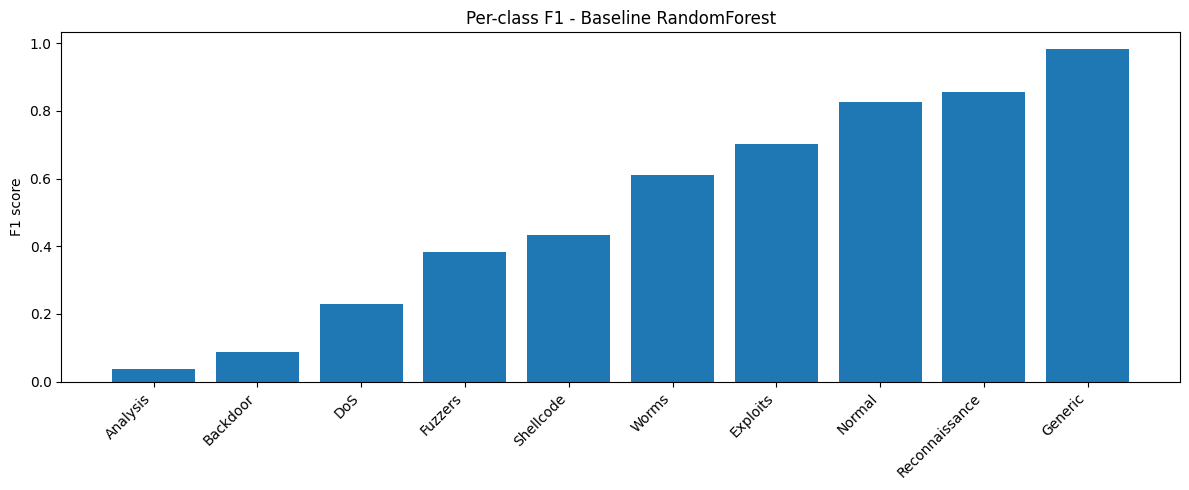

In [5]:
f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)

plt.figure(figsize=(12, 5))
order = np.argsort(f1_per_class)
plt.bar(np.array(class_names)[order], f1_per_class[order])
plt.xticks(rotation=45, ha='right')
plt.ylabel('F1 score')
plt.title('Per-class F1 - Baseline RandomForest')
plt.tight_layout()
plt.show()

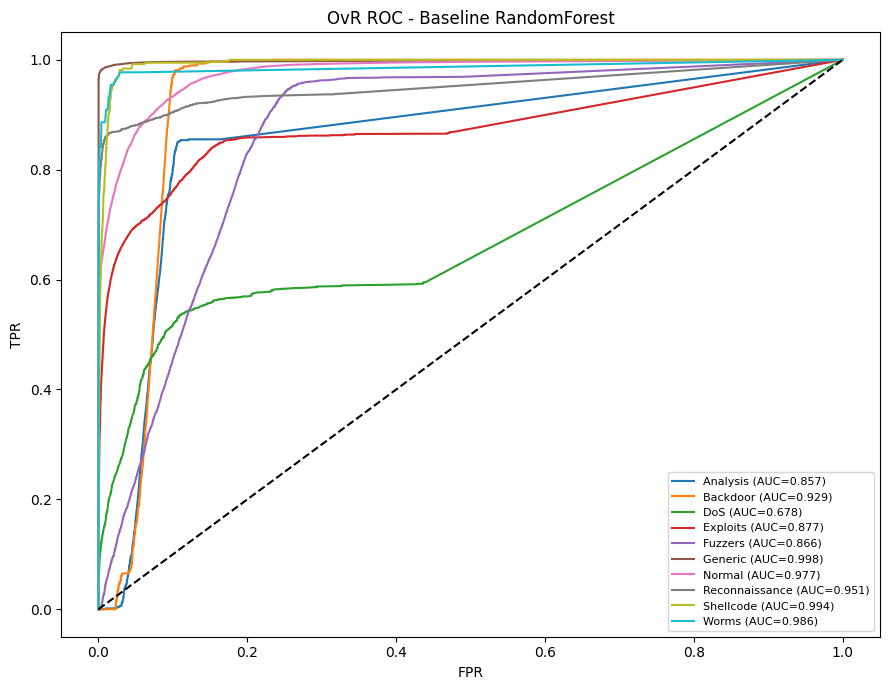

In [6]:
y_bin = label_binarize(y_test, classes=list(range(num_classes)))

plt.figure(figsize=(9, 7))
for i, cls in enumerate(class_names):
    if y_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f'{cls} (AUC={auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('OvR ROC - Baseline RandomForest')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

Binary (Normal vs Anomaly) metrics
Accuracy : 0.8630301705290774
Precision: 0.8099346547989589
Recall   : 0.9815803405982529
F1       : 0.8875347807441832
              precision    recall  f1-score   support

      Normal       0.97      0.72      0.82     37000
     Anomaly       0.81      0.98      0.89     45332

    accuracy                           0.86     82332
   macro avg       0.89      0.85      0.86     82332
weighted avg       0.88      0.86      0.86     82332



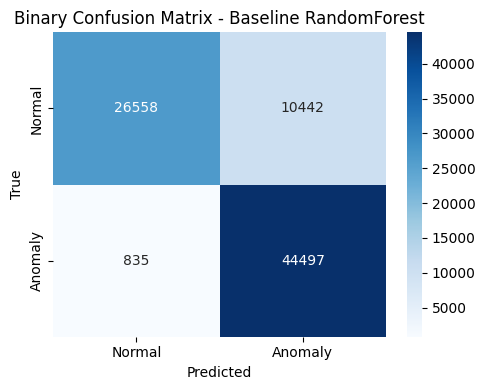

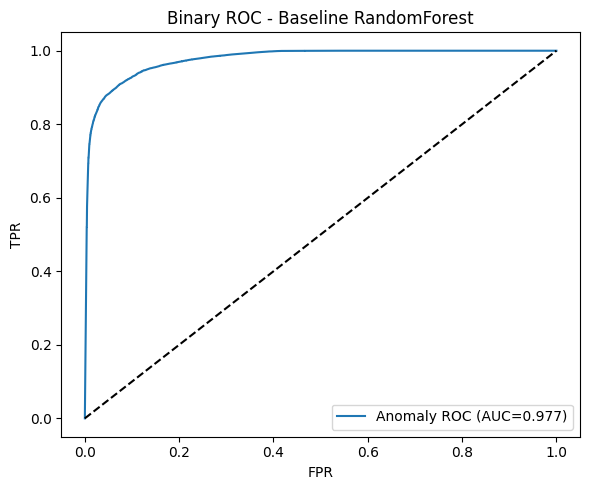

In [7]:
# Binary evaluation: Normal (0) vs Anomaly (1)
normal_candidates = [i for i, c in enumerate(class_names) if str(c).strip().lower() == 'normal']
if len(normal_candidates) == 0:
    raise ValueError("Could not find 'Normal' class in label encoder classes.")

normal_idx = normal_candidates[0]

y_test_bin = (y_test != normal_idx).astype(int)
y_pred_bin = (y_pred != normal_idx).astype(int)

acc_bin = accuracy_score(y_test_bin, y_pred_bin)
prec_bin = precision_score(y_test_bin, y_pred_bin, zero_division=0)
rec_bin = recall_score(y_test_bin, y_pred_bin, zero_division=0)
f1_bin = f1_score(y_test_bin, y_pred_bin, zero_division=0)

print('Binary (Normal vs Anomaly) metrics')
print('Accuracy :', acc_bin)
print('Precision:', prec_bin)
print('Recall   :', rec_bin)
print('F1       :', f1_bin)
print(classification_report(y_test_bin, y_pred_bin, target_names=['Normal', 'Anomaly'], zero_division=0))

cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Binary Confusion Matrix - Baseline RandomForest')
plt.tight_layout()
plt.show()

anomaly_score = 1.0 - probs[:, normal_idx]
auc_bin = roc_auc_score(y_test_bin, anomaly_score)
fpr_bin, tpr_bin, _ = roc_curve(y_test_bin, anomaly_score)

plt.figure(figsize=(6, 5))
plt.plot(fpr_bin, tpr_bin, label=f'Anomaly ROC (AUC={auc_bin:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Binary ROC - Baseline RandomForest')
plt.legend()
plt.tight_layout()
plt.show()